# Sport Recife 2026 — Análise de Evolução por Fase

Divide a temporada em três fases para avaliar a evolução do time:

| Fase | Nome | Critério |
|------|------|----------|
| 1 | **Sport com sub20** | Primeiros 3 jogos do ano |
| 2 | **Pré-Série B** | Do jogo 4 até a estreia na Série B (inclusive) |
| 3 | **Márcio Goiano** | Jogos após a estreia na Série B |

Fontes:
- `data/processed/2026/sport/sport_2026_results.csv`
- `data/processed/2026/sport/sport_2026_team_match_stats.csv`

Saída:
- `data/processed/2026/sport/sport_2026_fases.csv`

In [1]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use('ggplot')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

RESULTS_PATH = Path('../data/processed/2026/sport/sport_2026_results.csv')
STATS_PATH   = Path('../data/processed/2026/sport/sport_2026_team_match_stats.csv')
OUTPUT_CSV   = Path('../data/processed/2026/sport/sport_2026_fases.csv')

TEAM_NAME = 'Sport Recife'

# Fase 1: primeiros 3 jogos
FASE1_N_JOGOS = 3

# Fase 2 termina na estreia da Série B (inclusive)
SERIE_B_DEBUT_TS = pd.Timestamp('2026-03-21T23:30:00', tz='UTC')

FASE_LABELS = {
    1: 'Fase 1 — Sport sub20',
    2: 'Fase 2 — Pré-Série B',
    3: 'Fase 3 — Márcio Goiano',
}
FASE_COLORS = {1: '#FDE68A', 2: '#BAE6FD', 3: '#BBF7D0'}

In [2]:
results = pd.read_csv(RESULTS_PATH)
stats   = pd.read_csv(STATS_PATH)

results['match_date_utc'] = pd.to_datetime(results['match_date_utc'], utc=True)

# O mesmo jogo pode aparecer mais de uma vez no stats CSV (fase de grupos + playoffs).
# Mantemos apenas uma linha por source_url em cada perspectiva.
sport_stats = (
    stats.loc[stats['team_name'].eq(TEAM_NAME)]
    .drop_duplicates(subset='source_url', keep='first')
    .copy()
)
opp_stats = (
    stats.loc[~stats['team_name'].eq(TEAM_NAME)]
    .drop_duplicates(subset='source_url', keep='first')
    .copy()
)

matches = (
    results
    .merge(
        sport_stats[['source_url', 'expected_goals', 'possession', 'data_status']].rename(
            columns={'expected_goals': 'xg_for', 'data_status': 'stats_status'}
        ),
        on='source_url', how='left',
    )
    .merge(
        opp_stats[['source_url', 'team_name', 'expected_goals']].rename(
            columns={'team_name': 'opp_name_stats', 'expected_goals': 'xg_against'}
        ),
        on='source_url', how='left',
    )
)

matches['is_home']       = matches['home_team'].eq(TEAM_NAME)
matches['opponent']      = np.where(matches['is_home'], matches['away_team'], matches['home_team'])
matches['goals_for']     = np.where(matches['is_home'], matches['home_score'], matches['away_score'])
matches['goals_against'] = np.where(matches['is_home'], matches['away_score'], matches['home_score'])
matches['points']        = matches['sport_outcome'].map({'win': 3, 'draw': 1, 'loss': 0})
matches['xg_diff']       = matches['xg_for'] - matches['xg_against']

matches = matches.sort_values('match_date_utc').reset_index(drop=True)
matches['jogo_num'] = range(1, len(matches) + 1)

print(f'Total de jogos carregados: {len(matches)}')

Total de jogos carregados: 19


In [3]:
def assign_phase(row):
    if row['jogo_num'] <= FASE1_N_JOGOS:
        return 1
    elif row['match_date_utc'] <= SERIE_B_DEBUT_TS:
        return 2
    else:
        return 3

matches['fase']       = matches.apply(assign_phase, axis=1)
matches['fase_label'] = matches['fase'].map(FASE_LABELS)

# Exibição resumida
cols_display = [
    'jogo_num', 'fase_label', 'match_date_utc', 'competition_name',
    'opponent', 'goals_for', 'goals_against', 'sport_outcome',
    'xg_for', 'xg_against', 'xg_diff', 'possession', 'stats_status',
]
display(matches[cols_display].assign(
    match_date_utc=lambda df: df['match_date_utc'].dt.strftime('%Y-%m-%d')
).to_string(index=False))

' jogo_num             fase_label match_date_utc                 competition_name               opponent  goals_for  goals_against sport_outcome  xg_for  xg_against  xg_diff  possession             stats_status\n        1   Fase 1 — Sport sub20     2026-01-10           Pernambucano, Serie A1              AD Jaguar          2              2          draw    1.74        0.80     0.94       54.00 advanced_stats_confirmed\n        2   Fase 1 — Sport sub20     2026-01-15           Pernambucano, Serie A1                  Retrô          2              0           win     NaN         NaN      NaN         NaN   advanced_stats_missing\n        3   Fase 1 — Sport sub20     2026-01-18           Pernambucano, Serie A1                Náutico          0              4          loss    3.08        0.69     2.39       47.00 advanced_stats_confirmed\n        4   Fase 2 — Pré-Série B     2026-01-21           Pernambucano, Serie A1         Decisão Goiana          5              0           win    3.02    

In [4]:
# Resumo por fase
def phase_summary(df):
    rows = []
    for fase, grp in df.groupby('fase'):
        rows.append({
            'fase': FASE_LABELS[fase],
            'jogos': len(grp),
            'V': grp['sport_outcome'].eq('win').sum(),
            'E': grp['sport_outcome'].eq('draw').sum(),
            'D': grp['sport_outcome'].eq('loss').sum(),
            'pts': grp['points'].sum(),
            'aprov_%': round(grp['points'].sum() / (len(grp) * 3) * 100, 1),
            'gols_pro': int(grp['goals_for'].sum()),
            'gols_contra': int(grp['goals_against'].sum()),
            'saldo': int(grp['goals_for'].sum() - grp['goals_against'].sum()),
            'xg_pro': round(grp['xg_for'].sum(min_count=1), 2),
            'xg_contra': round(grp['xg_against'].sum(min_count=1), 2),
            'xg_diff': round(grp['xg_diff'].sum(min_count=1), 2),
            'posse_media_%': round(grp['possession'].mean(), 1),
        })
    return pd.DataFrame(rows)

resumo = phase_summary(matches)
print('Resumo por fase')
display(resumo)

Resumo por fase


,fase,jogos,V,E,D,pts,aprov_%,gols_pro,gols_contra,saldo,xg_pro,xg_contra,xg_diff,posse_media_%
0,Fase 1 — Sport sub20,3,1,1,1,4,44.40,4,6,-2,4.82,1.49,3.33,50.50
1,Fase 2 — Pré-Série B,12,8,3,1,27,75.00,31,17,14,15.85,13.81,2.04,59.10
2,Fase 3 — Márcio Goiano,4,3,1,0,10,83.30,6,3,3,4.44,5.81,-1.37,52.50


In [5]:
# Exporta CSV com demarcação de fase
export_cols = [
    'jogo_num', 'fase', 'fase_label',
    'match_date_utc', 'competition_name', 'competition_round',
    'opponent', 'is_home',
    'goals_for', 'goals_against', 'sport_outcome', 'points',
    'xg_for', 'xg_against', 'xg_diff',
    'possession', 'stats_status',
]
OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)
matches[export_cols].to_csv(OUTPUT_CSV, index=False)
print(f'CSV exportado: {OUTPUT_CSV}  ({len(matches)} jogos)')

CSV exportado: ..\data\processed\2026\sport\sport_2026_fases.csv  (19 jogos)


## Gráfico de Dispersão — Evolução do xG no Tempo

- **Eixo X:** Data do jogo
- **Eixo Y:** xG (pontos azuis = xG a favor / pontos vermelhos = xG contra)
- Linhas verticais delimitam as fases
- Fundo colorido identifica cada fase

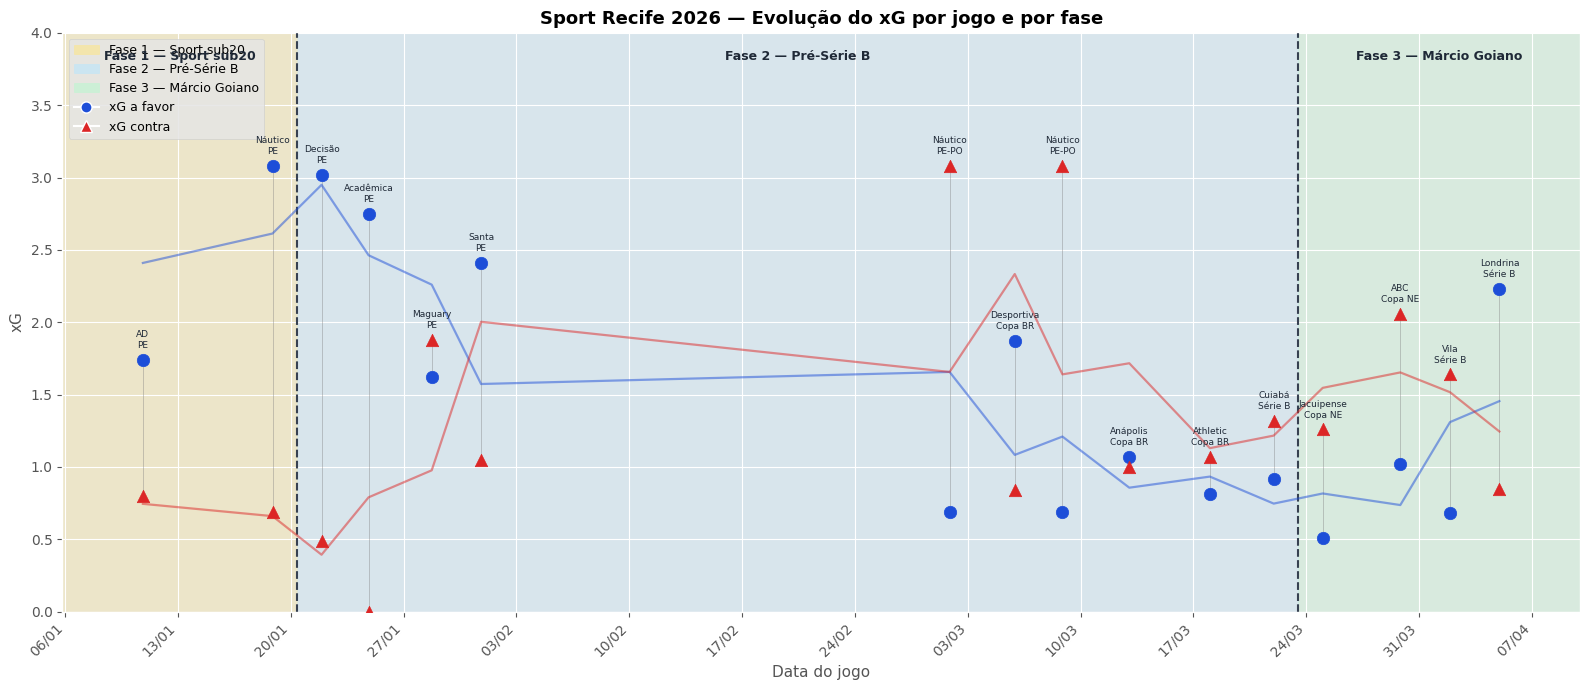

Gráfico salvo.


In [6]:
COMP_ABBREV = {
    'Pernambucano, Serie A1':           'PE',
    'Pernambucano, Serie A1, Playoffs': 'PE-PO',
    'Copa Betano do Brasil':            'Copa BR',
    'Brasileirão Série B':              'Série B',
    'Copa do Nordeste':                 'Copa NE',
}

fig, ax = plt.subplots(figsize=(16, 7))

# ── 1. Limites do eixo X ──────────────────────────────────────────────────────
x_min = matches['match_date_utc'].min() - pd.Timedelta(days=5)
x_max = matches['match_date_utc'].max() + pd.Timedelta(days=5)

# ── 2. Fronteiras exatas entre fases ─────────────────────────────────────────
all_phases  = sorted(matches['fase'].unique())
phase_last  = {f: matches.loc[matches['fase'].eq(f), 'match_date_utc'].max() for f in all_phases}
phase_first = {f: matches.loc[matches['fase'].eq(f), 'match_date_utc'].min() for f in all_phases}

boundaries = []
for i in range(len(all_phases) - 1):
    end   = phase_last[all_phases[i]]
    start = phase_first[all_phases[i + 1]]
    boundaries.append(end + (start - end) / 2)

span_limits = [x_min] + boundaries + [x_max]

# ── 3. Fundo colorido por fase ────────────────────────────────────────────────
for i, fase_id in enumerate(all_phases):
    ax.axvspan(span_limits[i], span_limits[i + 1],
               color=FASE_COLORS[fase_id], alpha=0.30, zorder=0)

# ── 4. Linhas verticais nas fronteiras ────────────────────────────────────────
for b in boundaries:
    ax.axvline(b, color='#374151', linewidth=1.5, linestyle='--', zorder=2)

# ── 5. Segmento vertical conectando os dois pontos de cada jogo ───────────────
for _, row in matches.iterrows():
    if pd.notna(row['xg_for']) and pd.notna(row['xg_against']):
        ax.plot([row['match_date_utc'], row['match_date_utc']],
                [row['xg_for'], row['xg_against']],
                color='gray', linewidth=0.7, alpha=0.4, zorder=2)

# ── 6. Linha de tendência suavizada (rolling 3, centrado) ────────────────────
for col, color in [('xg_for', '#1D4ED8'), ('xg_against', '#DC2626')]:
    trend = matches[['match_date_utc', col]].dropna(subset=[col]).copy()
    trend['rolling'] = trend[col].rolling(3, center=True, min_periods=1).mean()
    ax.plot(trend['match_date_utc'].values, trend['rolling'].values,
            color=color, linewidth=1.6, alpha=0.50, zorder=3)

# ── 7. Scatter xG a favor ─────────────────────────────────────────────────────
has_xg = matches['xg_for'].notna()
ax.scatter(matches.loc[has_xg, 'match_date_utc'].values,
           matches.loc[has_xg, 'xg_for'].values,
           color='#1D4ED8', s=80, zorder=5, label='xG a favor', marker='o')

# ── 8. Scatter xG contra ──────────────────────────────────────────────────────
has_xga = matches['xg_against'].notna()
ax.scatter(matches.loc[has_xga, 'match_date_utc'].values,
           matches.loc[has_xga, 'xg_against'].values,
           color='#DC2626', s=80, zorder=5, label='xG contra', marker='^')

# ── 9. Rótulo por jogo: adversário + competição ───────────────────────────────
for _, row in matches.iterrows():
    xg_vals = [v for v in [row.get('xg_for'), row.get('xg_against')] if pd.notna(v)]
    if not xg_vals:
        continue
    y_top   = max(xg_vals)
    opp     = str(row['opponent']).split()[0]
    comp    = COMP_ABBREV.get(str(row['competition_name']), str(row['competition_name']))
    ax.annotate(
        f"{opp}\n{comp}",
        xy=(row['match_date_utc'], y_top),
        xytext=(0, 7), textcoords='offset points',
        fontsize=6.5, color='#1F2937', ha='center', va='bottom', zorder=6,
        linespacing=1.3,
    )

# ── 10. Ajusta ylim e rótulos de fase ────────────────────────────────────────
all_yvals = pd.concat([matches['xg_for'], matches['xg_against']]).dropna()
y_max = all_yvals.max()
ax.set_ylim(0, y_max * 1.30)

for i, fase_id in enumerate(all_phases):
    mid_x = span_limits[i] + (span_limits[i + 1] - span_limits[i]) / 2
    ax.text(mid_x, y_max * 1.26, FASE_LABELS[fase_id],
            ha='center', va='top', fontsize=9, fontweight='bold',
            color='#1F2937', zorder=7)

# ── 11. Formatação ────────────────────────────────────────────────────────────
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.xticks(rotation=45, ha='right')
ax.set_xlim(x_min, x_max)
ax.set_xlabel('Data do jogo', fontsize=11)
ax.set_ylabel('xG', fontsize=11)
ax.set_title('Sport Recife 2026 — Evolução do xG por jogo e por fase', fontsize=13, fontweight='bold')

legend_handles = [
    mpatches.Patch(color=FASE_COLORS[1], alpha=0.6, label=FASE_LABELS[1]),
    mpatches.Patch(color=FASE_COLORS[2], alpha=0.6, label=FASE_LABELS[2]),
    mpatches.Patch(color=FASE_COLORS[3], alpha=0.6, label=FASE_LABELS[3]),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#1D4ED8', markersize=8, label='xG a favor'),
    plt.Line2D([0],[0], marker='^', color='w', markerfacecolor='#DC2626', markersize=8, label='xG contra'),
]
ax.legend(handles=legend_handles, loc='upper left', fontsize=9, framealpha=0.85)

plt.tight_layout()
plt.savefig('../data/processed/2026/sport/sport_2026_xg_evolucao_fases.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo.')

In [7]:
# Métricas médias por fase para comparação direta
medias = (
    matches
    .groupby('fase_label', sort=False)
    .agg(
        jogos=('jogo_num', 'count'),
        xg_for_media=('xg_for', 'mean'),
        xg_against_media=('xg_against', 'mean'),
        xg_diff_media=('xg_diff', 'mean'),
        gols_pro_media=('goals_for', 'mean'),
        gols_contra_media=('goals_against', 'mean'),
        posse_media=('possession', 'mean'),
        aproveitamento_pct=('points', lambda s: s.sum() / (len(s) * 3) * 100),
    )
    .round(2)
    .reset_index()
)
print('Médias por fase (por jogo)')
display(medias)

Médias por fase (por jogo)


,fase_label,jogos,xg_for_media,xg_against_media,xg_diff_media,gols_pro_media,gols_contra_media,posse_media,aproveitamento_pct
0,Fase 1 — Sport sub20,3,2.41,0.74,1.66,1.33,2.00,50.50,44.44
1,Fase 2 — Pré-Série B,12,1.58,1.38,0.20,2.58,1.42,59.11,75.00
2,Fase 3 — Márcio Goiano,4,1.11,1.45,-0.34,1.50,0.75,52.50,83.33
